# DO NOT RUN

In [ ]:
from src.load import MasterDataset
from src.transform import make_transform

ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

print(ds[0][0].min(), ds[0][0].max())  # gravity input (input)
print(ds[0][1].min(), ds[0][1].max())  # true density model (label)

tensor(-0.4959) tensor(7.3987e-05)
tensor(0.) tensor(0.6066)


# ADAM + WEIGHTED MSE

In [ ]:
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from src.load import MasterDataset, _worker_init_fn
from src.transform import make_transform
from src.nn import GravInvNet  # your model

# --------- 1) Setup ---------
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

def collate(b):
    # Support 3- or 4-tuples from Dataset
    out = []
    for item in b:
        if len(item) == 4:
            x,y,m,_ = item
        else:
            x,y,m = item
        out.append((x,y,m))
    xs, ys, ms = zip(*out)
    return torch.stack(xs), torch.stack(ys), torch.stack(ms)

ld = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0,
                worker_init_fn=_worker_init_fn, collate_fn=collate)

# Grab ONE batch and freeze it (no further shuffling)
x, y, m = next(iter(ld))
x, y, m = x.to(device), y.to(device), m.to(device)

print("x", x.shape, "y", y.shape, "m", m.shape)  # expect (B,1,32,32), (B,16,32,32), (B,16,32,32)

# --------- 2) Model & loss ---------
model = GravInvNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

# # masked/weighted MSE so it can learn non-zero regions fast
def masked_mse(pred, target, mask, w_bg=1.0, w_act=10.0):
    act = (mask > 0.5).float()
    bg  = 1.0 - act
    # use sum then divide by total voxels so weights are meaningful
    loss = (
        w_act * F.mse_loss(pred*act, target*act, reduction="sum") +
        w_bg  * F.mse_loss(pred*bg,  target*bg,  reduction="sum")
    ) / pred.numel()
    return loss

# --------- 3) Train ONLY on this batch ---------
model.train()
best = float("inf")
for step in range(2000):   # plenty of steps; should fall fast
    opt.zero_grad(set_to_none=True)
    pred = model(x)                        # (B,16,32,32)
    loss = masked_mse(pred, y, m, w_bg=0.5, w_act=20.0)  # stronger weight on active cells
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()

    if loss.item() < best:
        best = loss.item()
    if step % 100 == 0 or step < 10:
        with torch.no_grad():
            mse_all = F.mse_loss(pred, y).item()
        print(f"step {step:4d} | masked_loss {loss.item():.6f} | mse_all {mse_all:.6f}")

print("Best (masked) loss:", best)


x torch.Size([8, 1, 32, 32]) y torch.Size([8, 16, 32, 32]) m torch.Size([8, 16, 32, 32])
step    0 | masked_loss 3.085344 | mse_all 0.154267
step    1 | masked_loss 64.508705 | mse_all 3.225435
step    2 | masked_loss 26.561272 | mse_all 1.328064
step    3 | masked_loss 9.633286 | mse_all 0.481664
step    4 | masked_loss 3.080557 | mse_all 0.154028
step    5 | masked_loss 1.026814 | mse_all 0.051341
step    6 | masked_loss 0.474666 | mse_all 0.023733
step    7 | masked_loss 0.298192 | mse_all 0.014910
step    8 | masked_loss 0.224152 | mse_all 0.011208
step    9 | masked_loss 0.190650 | mse_all 0.009532
step  100 | masked_loss 0.028984 | mse_all 0.001449
step  200 | masked_loss 0.014524 | mse_all 0.000726
step  300 | masked_loss 0.012720 | mse_all 0.000636
step  400 | masked_loss 0.005043 | mse_all 0.000252
step  500 | masked_loss 0.001286 | mse_all 0.000064
step  600 | masked_loss 0.000361 | mse_all 0.000018
step  700 | masked_loss 0.000212 | mse_all 0.000011
step  800 | masked_loss 0

# ADAM

In [2]:
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from src.load import MasterDataset, _worker_init_fn
from src.transform import make_transform
from src.nn import GravInvNet  # your model

# --------- 1) Setup ---------
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

def collate(b):
    # Support 3- or 4-tuples from Dataset
    out = []
    for item in b:
        if len(item) == 4:
            x,y,m,_ = item
        else:
            x,y,m = item
        out.append((x,y,m))
    xs, ys, ms = zip(*out)
    return torch.stack(xs), torch.stack(ys), torch.stack(ms)

ld = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0,
                worker_init_fn=_worker_init_fn, collate_fn=collate)

# Grab ONE batch and freeze it (no further shuffling)
x, y, m = next(iter(ld))
x, y, m = x.to(device), y.to(device), m.to(device)

print("x", x.shape, "y", y.shape, "m", m.shape)  # expect (B,1,32,32), (B,16,32,32), (B,16,32,32)

# --------- 2) Model & loss ---------
model = GravInvNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

# masked_mse=lambda p,t,m:((p-t)[m]**2).mean()

def masked_mse(pred, tgt, mask, eps=1e-12):
    m = mask.float()
    diff2 = (pred - tgt).square()
    num = (diff2 * m).sum()
    den = m.sum().clamp_min(eps)
    return num / den

# --------- 3) Train ONLY on this batch ---------
model.train()
best = float("inf")
for step in range(2000):   # plenty of steps; should fall fast
    opt.zero_grad(set_to_none=True)
    pred = model(x)                        # (B,16,32,32)
    loss = masked_mse(pred, y, m)  # stronger weight on active cells
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()

    if loss.item() < best:
        best = loss.item()
    if step % 100 == 0 or step < 10:
        with torch.no_grad():
            mse_all = F.mse_loss(pred, y).item()
        print(f"step {step:4d} | masked_loss {loss.item():.6f} | mse_all {mse_all:.6f}")

print("Best (masked) loss:", best)


x torch.Size([8, 1, 32, 32]) y torch.Size([8, 16, 32, 32]) m torch.Size([8, 16, 32, 32])
step    0 | masked_loss 0.154267 | mse_all 0.154267
step    1 | masked_loss 3.225436 | mse_all 3.225436
step    2 | masked_loss 1.127728 | mse_all 1.127728
step    3 | masked_loss 0.327784 | mse_all 0.327784
step    4 | masked_loss 0.109824 | mse_all 0.109824
step    5 | masked_loss 0.052506 | mse_all 0.052506
step    6 | masked_loss 0.033960 | mse_all 0.033960
step    7 | masked_loss 0.025847 | mse_all 0.025847
step    8 | masked_loss 0.021364 | mse_all 0.021364
step    9 | masked_loss 0.018495 | mse_all 0.018495
step  100 | masked_loss 0.002538 | mse_all 0.002538
step  200 | masked_loss 0.002124 | mse_all 0.002124
step  300 | masked_loss 0.001010 | mse_all 0.001010
step  400 | masked_loss 0.000746 | mse_all 0.000746
step  500 | masked_loss 0.000668 | mse_all 0.000668
step  600 | masked_loss 0.000634 | mse_all 0.000634
step  700 | masked_loss 0.000572 | mse_all 0.000572
step  800 | masked_loss 0.0

# SGD

In [4]:
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from src.load import MasterDataset, _worker_init_fn
from src.transform import make_transform
from src.nn import GravInvNet  # your model

# --------- 1) Setup ---------
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

def collate(b):
    # Support 3- or 4-tuples from Dataset
    out = []
    for item in b:
        if len(item) == 4:
            x,y,m,_ = item
        else:
            x,y,m = item
        out.append((x,y,m))
    xs, ys, ms = zip(*out)
    return torch.stack(xs), torch.stack(ys), torch.stack(ms)

ld = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0,
                worker_init_fn=_worker_init_fn, collate_fn=collate)

# Grab ONE batch and freeze it (no further shuffling)
x, y, m = next(iter(ld))
x, y, m = x.to(device), y.to(device), m.to(device)

print("x", x.shape, "y", y.shape, "m", m.shape)  # expect (B,1,32,32), (B,16,32,32), (B,16,32,32)

# --------- 2) Model & loss ---------
model = GravInvNet().to(device)
opt = torch.optim.SGD(model.parameters(),lr=1e-2,momentum=0.9,weight_decay=1e-4)

def masked_mse(pred, tgt, mask, eps=1e-12):
    m = mask.float()
    diff2 = (pred - tgt).square()
    num = (diff2 * m).sum()
    den = m.sum().clamp_min(eps)
    return num / den

# --------- 3) Train ONLY on this batch ---------
model.train()
best = float("inf")
for step in range(2000):   # plenty of steps; should fall fast
    opt.zero_grad(set_to_none=True)
    pred = model(x)                        # (B,16,32,32)
    loss = masked_mse(pred, y, m)  # stronger weight on active cells
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()

    if loss.item() < best:
        best = loss.item()
    if step % 100 == 0 or step < 10:
        with torch.no_grad():
            mse_all = F.mse_loss(pred, y).item()
        print(f"step {step:4d} | masked_loss {loss.item():.6f} | mse_all {mse_all:.6f}")

print("Best (masked) loss:", best)


x torch.Size([8, 1, 32, 32]) y torch.Size([8, 16, 32, 32]) m torch.Size([8, 16, 32, 32])
step    0 | masked_loss 0.154267 | mse_all 0.154267
step    1 | masked_loss 0.092642 | mse_all 0.092642
step    2 | masked_loss 0.092020 | mse_all 0.092020
step    3 | masked_loss 0.077020 | mse_all 0.077020
step    4 | masked_loss 0.044856 | mse_all 0.044856
step    5 | masked_loss 0.039013 | mse_all 0.039013
step    6 | masked_loss 0.039209 | mse_all 0.039209
step    7 | masked_loss 0.030957 | mse_all 0.030957
step    8 | masked_loss 0.022994 | mse_all 0.022994
step    9 | masked_loss 0.019137 | mse_all 0.019137
step  100 | masked_loss 0.001017 | mse_all 0.001017
step  200 | masked_loss 0.000740 | mse_all 0.000740
step  300 | masked_loss 0.000623 | mse_all 0.000623
step  400 | masked_loss 0.000552 | mse_all 0.000552
step  500 | masked_loss 0.000503 | mse_all 0.000503
step  600 | masked_loss 0.000469 | mse_all 0.000469
step  700 | masked_loss 0.000444 | mse_all 0.000444
step  800 | masked_loss 0.0

# ADAMW

In [5]:
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from src.load import MasterDataset, _worker_init_fn
from src.transform import make_transform
from src.nn import GravInvNet  # your model

# --------- 1) Setup ---------
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = MasterDataset("data/master.h5")
ds.transform = make_transform(ds.shape_cells)

def collate(b):
    # Support 3- or 4-tuples from Dataset
    out = []
    for item in b:
        if len(item) == 4:
            x,y,m,_ = item
        else:
            x,y,m = item
        out.append((x,y,m))
    xs, ys, ms = zip(*out)
    return torch.stack(xs), torch.stack(ys), torch.stack(ms)

ld = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0,
                worker_init_fn=_worker_init_fn, collate_fn=collate)

# Grab ONE batch and freeze it (no further shuffling)
x, y, m = next(iter(ld))
x, y, m = x.to(device), y.to(device), m.to(device)

print("x", x.shape, "y", y.shape, "m", m.shape)  # expect (B,1,32,32), (B,16,32,32), (B,16,32,32)

# --------- 2) Model & loss ---------
model = GravInvNet().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def masked_mse(pred, tgt, mask, eps=1e-12):
    m = mask.float()
    diff2 = (pred - tgt).square()
    num = (diff2 * m).sum()
    den = m.sum().clamp_min(eps)
    return num / den

# --------- 3) Train ONLY on this batch ---------
model.train()
best = float("inf")
for step in range(2000):   # plenty of steps; should fall fast
    opt.zero_grad(set_to_none=True)
    pred = model(x)                        # (B,16,32,32)
    loss = masked_mse(pred, y, m)  # stronger weight on active cells
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()

    if loss.item() < best:
        best = loss.item()
    if step % 100 == 0 or step < 10:
        with torch.no_grad():
            mse_all = F.mse_loss(pred, y).item()
        print(f"step {step:4d} | masked_loss {loss.item():.6f} | mse_all {mse_all:.6f}")

print("Best (masked) loss:", best)


x torch.Size([8, 1, 32, 32]) y torch.Size([8, 16, 32, 32]) m torch.Size([8, 16, 32, 32])
step    0 | masked_loss 0.154267 | mse_all 0.154267
step    1 | masked_loss 3.225435 | mse_all 3.225435
step    2 | masked_loss 1.127728 | mse_all 1.127728
step    3 | masked_loss 0.327805 | mse_all 0.327805
step    4 | masked_loss 0.109834 | mse_all 0.109834
step    5 | masked_loss 0.052515 | mse_all 0.052515
step    6 | masked_loss 0.033967 | mse_all 0.033967
step    7 | masked_loss 0.025852 | mse_all 0.025852
step    8 | masked_loss 0.021366 | mse_all 0.021366
step    9 | masked_loss 0.018494 | mse_all 0.018494
step  100 | masked_loss 0.002539 | mse_all 0.002539
step  200 | masked_loss 0.002124 | mse_all 0.002124
step  300 | masked_loss 0.001010 | mse_all 0.001010
step  400 | masked_loss 0.000746 | mse_all 0.000746
step  500 | masked_loss 0.000668 | mse_all 0.000668
step  600 | masked_loss 0.000635 | mse_all 0.000635
step  700 | masked_loss 0.000571 | mse_all 0.000571
step  800 | masked_loss 0.0

In [99]:
from pathlib import Path
from src.load import MasterDataset

path = Path("data/singleblock.h5")

ds = MasterDataset(path); nx, ny, nz = map(int, ds.shape_cells)

ds.hz[0]

np.float32(50.0)

In [100]:
import numpy as np

# Load the saved indices
data = np.load("training/split/idx_init.npz")

# Access validation indices
va_indices = data["va"]

# (Optional) access training indices
tr_indices = data["tr"]

print("Validation indices:", va_indices)
print("Training indices:", tr_indices)


Validation indices: [15370 10051   200 ...   566  6265  6726]
Training indices: [16044 15558  2137 ... 17880  4432 11040]


In [108]:
len(tr_indices)
tr_indices[200]

np.int64(6069)

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm, colormaps

def plot_density_contrast_3D_voxels(mesh, ind_active, density_values):
    """
    Plot 3D voxel grid showing:
      - semi-transparent active (earth) volume
      - solid blocks colored by density contrast
    Args:
        mesh: SimPEG/discretize mesh object
        ind_active: boolean indices for active cells
        density_values: array of density contrast values for active cells
    """
    # Initialize volumes
    full_active = np.zeros(mesh.nC, dtype=bool)
    full_active[ind_active] = True

    full_density = np.zeros(mesh.nC, dtype=float)
    full_density[ind_active] = density_values

    active_vol  = full_active.reshape(mesh.shape_cells, order="F")
    density_vol = full_density.reshape(mesh.shape_cells, order="F")

    # Grid edges
    x_edges = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y_edges = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z_edges = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    X, Y, Z = np.meshgrid(x_edges, y_edges, z_edges, indexing="ij")

    # Normalize colormap for density
    cmap = colormaps["plasma"]

    # Convert voxel colors
    facecolors = cmap(density_vol)
    facecolors[..., -1] = np.where(density_vol > 0.5, 0.95, 0.0)  # alpha channel

    # Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Active volume (semi-transparent)
    ax.voxels(X, Y, Z, active_vol, facecolors="lightgray", edgecolor="none", alpha=0)

    # Density blocks
    density_vol = np.where(density_vol > 0.5, 0.95, 0.0)
    ax.voxels(X, Y, Z, density_vol, facecolors=facecolors, edgecolor="k", linewidth=0.2)

    # Aspect ratio and labels
    ax.set_box_aspect((np.sum(mesh.h[0]), np.sum(mesh.h[1]), np.sum(mesh.h[2])))
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("3D Density Contrast Distribution")

    # Add colorbar
    mappable = cm.ScalarMappable(cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.05)
    cbar.set_label("Density Contrast (g/cm³ or kg/m³)")

    # plt.tight_layout()
    # plt.show()


In [ ]:
import numpy as np
import pyvista as pv

def plot_density_contrast_3D_voxels(mesh, ind_active, density_values):
    """
    Plot 3D voxel grid showing:
      - semi-transparent active (earth) volume
      - solid blocks overlay for density anomalies
    """
    full_active = np.zeros(mesh.nC, dtype=bool)
    full_active[ind_active] = True
    full_density = np.zeros(mesh.nC, dtype=float)
    full_density[ind_active] = density_values
    active_vol  = full_active.reshape(mesh.shape_cells, order="F")
    density_vol = full_density.reshape(mesh.shape_cells, order="F")
    x_edges = mesh.x0[0] + np.r_[0.0, np.cumsum(mesh.h[0])]
    y_edges = mesh.x0[1] + np.r_[0.0, np.cumsum(mesh.h[1])]
    z_edges = mesh.x0[2] + np.r_[0.0, np.cumsum(mesh.h[2])]
    grid = pv.RectilinearGrid(x_edges, y_edges, z_edges)
    grid.cell_data["active"]  = active_vol.flatten(order="F").astype(np.uint8)
    grid.cell_data["density"] = density_vol.flatten(order="F").astype(float)
    dens_thresh = grid.threshold(value=0.5, scalars="density", invert=False)
    p = pv.Plotter()
    p.add_mesh(grid, scalars="active", opacity=0.4, show_edges=False, show_scalar_bar=False)
    p.add_mesh(
        dens_thresh,
        scalars="density",
        cmap="plasma",
        show_edges=True,
        line_width=0.2,
        clim=(0,1),
        scalar_bar_args={
            "title": "",
            "vertical": True,        
            "position_x": 0.94,      
            "position_y": 0.15,      
            "width": 0.04,          
            "height": 0.7,           
            "label_font_size": 14,
        }
    )
    p.show_bounds(
        grid="back",
        location="outer",
        ticks="both",
        xtitle="X (m)", ytitle="Y (m)", ztitle="Z (m)",
        font_size=12
    )
    p.add_text("Density Contrast (g/cc)", font_size=12, position="upper_edge")
    p.camera_position = "iso"
    p.camera.azimuth += 270
    p.show()


In [153]:
import numpy as np
import pyvista as pv

def plot_gravity_measurements(receiver_locations, dpred, 
                                 title="Gravity Anomaly (Z-component)",
                                 units="mGal", show_points=True, 
                                 cmap="bwr", ncontour=30):
    """
    Plot 2D gravity anomaly map using PyVista.
    """
    # Prepare data
    x, y = receiver_locations[:, 0], receiver_locations[:, 1]
    z = np.zeros_like(x)
    v_max = np.max(np.abs(dpred))

    # Create structured surface for visualization
    grid = pv.PolyData(np.c_[x, y, z])
    grid.point_data["anomaly"] = dpred

    # Create a triangulated surface for contouring
    surf = grid.delaunay_2d()
    
    # Create plotter
    p = pv.Plotter(window_size=[900, 700])
    p.set_background("white")

    # Add contour/filled map
    p.add_mesh(
        surf,
        scalars="anomaly",
        cmap=cmap,
        clim=(-v_max, v_max),
        smooth_shading=True,
        scalar_bar_args={
            "title": "",
            "vertical": True,
            "position_x": 0.87,
            "position_y": 0.2,
            "width": 0.04,
            "height": 0.6,
            "label_font_size": 12,
        }
    )

    # Optionally add station markers
    if show_points:
        p.add_points(
            grid,
            color="black",
            point_size=6,
            render_points_as_spheres=True,
        )

    # Add colorbar label (units)
    p.add_text(f"{units}", position="upper_right", font_size=12)
    p.add_text(title, position="upper_left", font_size=16)

    # Set


0.0 0.8794604539871216


/home/maxaalto/gravimetry_sims/.venv/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/maxaalto/gravimetry_sims/.venv/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


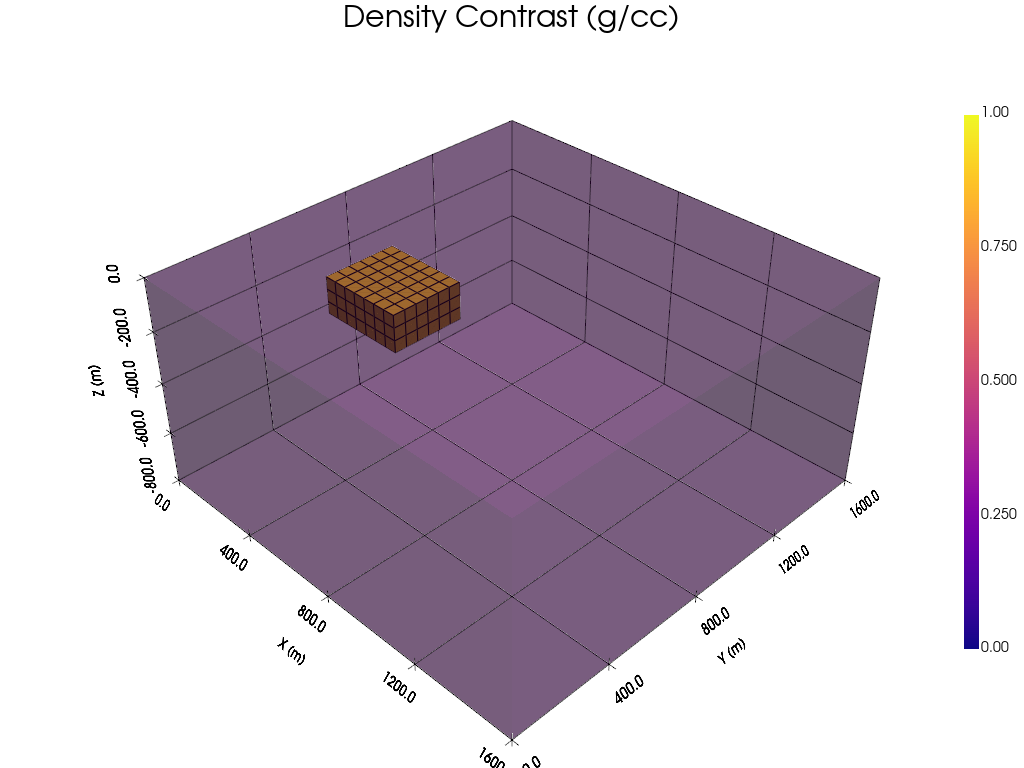

Loaded trained model from weights/singleblock.pt
[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00 4.8100443e-05
 2.6783065e-04]


/home/maxaalto/gravimetry_sims/.venv/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/maxaalto/gravimetry_sims/.venv/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


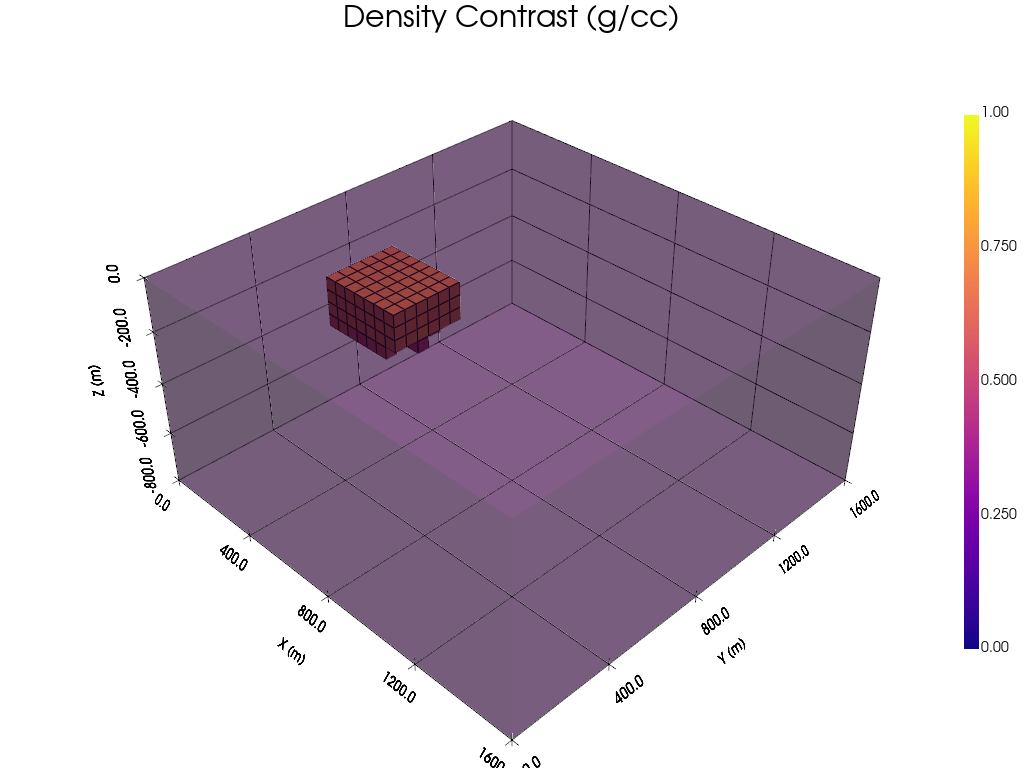

: 

In [ ]:
import numpy as np, torch
from pathlib import Path
# from src.viz.samples import plot_topography, plot_gravity_measurements, plot_density_contrast_3D_voxels
from src.gen.gen import create_mesh
from src.io.hdf5_i import MasterReader
from src.load import MasterDataset
from src.transform import make_transform
from src.nn import GravInvNet
from src.normalize import compute_stats, denorm

def inspect_truth(h5_path: Path, seed_index: int = 0):
    """Read one sample and return stuff."""
    ds = MasterDataset(h5_path); nx, ny, nz = map(int, ds.shape_cells)
    with MasterReader(h5_path) as mr:
        seed = mr.list_seeds()[seed_index]
        s = mr.read(seed)
    rx, gz = s["receiver_locations"], s["gz"]
    ind = s["ind_active"].astype(bool)                 
    true = np.zeros_like(ind, float)
    true[ind] = s["true_model"]
    z_dom = nz * ds.hz[0]           
    mesh = create_mesh(np.flip(rx, 0), n_xy=nx, n_z=nz, z_dom=z_dom)
    return s, rx, gz, (nx, ny, nz), ind, true, mesh

@torch.no_grad()
def inspect_prediction(sample: dict, shape_cells, stats,device, net: GravInvNet):
    """Run net on sample and return prediction."""
    x, _, _, _ = make_transform(shape_cells, stats)(sample) # (1,H,W)
    x = x.unsqueeze(0).to(device)                           # (1,1,H,W)
    net.eval()
    pred = net(x)[0]                                        # (Z,H,W)
    pred_full = pred.permute(2,1,0).cpu().numpy()           # (nx,ny,nz)
    return pred_full.reshape(-1)                            # (nx*ny*nz,)

def main():
    path = Path("data/singleblock.h5")
    sample, rx, gz, shape, ind, true, mesh = inspect_truth(path, seed_index=va_indices[201])
    print(true.min(), true.max())
    # plot_topography(rx)
    plot_gravity_measurements(rx, gz)
    plot_density_contrast_3D_voxels(mesh, ind, true)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = GravInvNet().to(device)
    ckpt_path = Path("weights/singleblock.pt")
    if ckpt_path.exists():
        state = torch.load(ckpt_path, map_location=device)
        net.load_state_dict(state["model"] if "model" in state else state)
        print(f"Loaded trained model from {ckpt_path}")
    else:
        print("Using untrained model.")
    stats = compute_stats(str(path))
    pred_flat = inspect_prediction(sample, shape, stats, device, net)
    pred_phys_flat = denorm(pred_flat, stats)           # physical units (e.g., g/cc)
    print(pred_phys_flat)
    plot_density_contrast_3D_voxels(mesh, ind, pred_phys_flat)

if __name__ == "__main__":
    main()

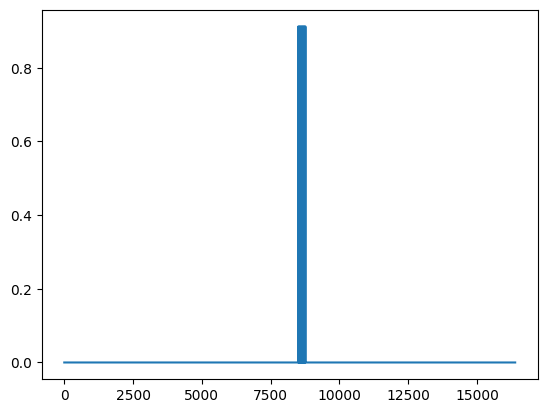

In [151]:
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("data/singleblock.h5")
sample, rx, gz, shape, ind, true, mesh = inspect_truth(path, seed_index=va_indices[0])
stats = compute_stats(str(path))
# plot_topography(rx)
# plot_gravity_measurements(rx, gz)
true.min(), true.max()

plt.plot(true)
plt.show()

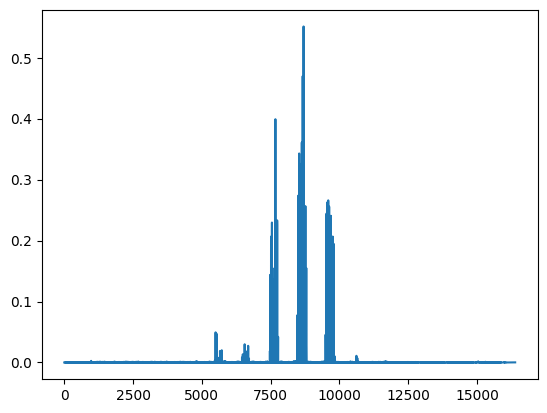

In [152]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = GravInvNet().to(device)
ckpt_path = Path("weights/singleblock.pt")
if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device)
    net.load_state_dict(state["model"] if "model" in state else state)
pred_flat = inspect_prediction(sample, shape, stats, device, net)
pred_phys_flat = denorm(pred_flat, stats)           # physical units (e.g., g/cc)

pred_phys_flat.min(), pred_phys_flat.max()

plt.plot(pred_phys_flat)
plt.show()

In [ ]:
import torch
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt

def compute_stats(h5_path):
    with h5py.File(h5_path, "r") as f:
        sample_keys = list(f["samples"].keys())
        s = f["samples"][sample_keys[2]]
        gz = s["gravity_data"][()][2::9]  # Every 9th value starting from index 2
        tm = s["true_model"][()]
    return gz, tm

gz, tm = compute_stats("data/single_block_v2.h5")
plt.hist(tm, bins=100)

In [19]:
tm_p

array([2.1567812, 2.09198  , 2.2540548, ..., 2.1609209, 2.0388575,
       2.1244392], shape=(13124,), dtype=float32)

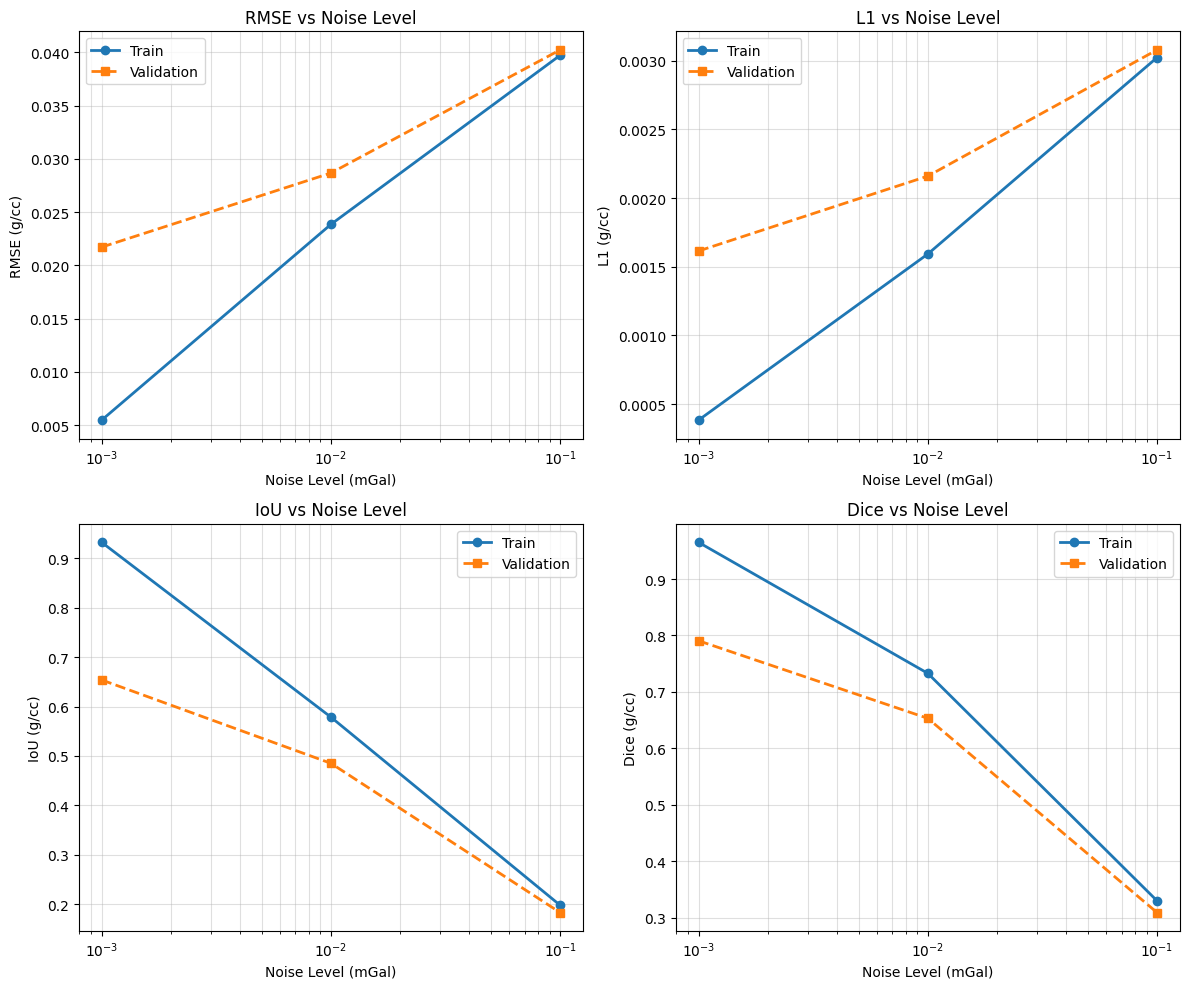

In [5]:
import matplotlib.pyplot as plt

# Data for each noise level
noise_levels = [0.001, 0.01, 0.1]

train_rmse = [0.005462, 0.023842, 0.039717]
val_rmse = [0.021705, 0.028662, 0.040226]

train_l1 = [0.000384, 0.001593, 0.003023]
val_l1 = [0.001615, 0.002160, 0.003079]

train_iou = [0.932446, 0.578470, 0.197541]
val_iou = [0.653828, 0.485023, 0.182750]

train_dice = [0.965042, 0.732950, 0.329911]
val_dice = [0.790684, 0.653219, 0.309026]

# Plot setup
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
metrics = [
    ("RMSE", train_rmse, val_rmse),
    ("L1", train_l1, val_l1),
    ("IoU", train_iou, val_iou),
    ("Dice", train_dice, val_dice)
]

for ax, (name, train_vals, val_vals) in zip(axs.flatten(), metrics):
    ax.plot(noise_levels, train_vals, 'o-', label="Train", linewidth=2)
    ax.plot(noise_levels, val_vals, 's--', label="Validation", linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("Noise Level (mGal)")
    ax.set_ylabel(f"{name} (g/cc)")
    ax.set_title(f"{name} vs Noise Level")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()